# Clinical Trial Dropout Prediction (04_Modeling_and_Evaluation)

## 1. Objective

This notebook focuses on the Machine Learning modeling and evaluation stage of the project.

The objective is to develop and compare two classification models for predicting participant dropout in a Phase III clinical trial:

- Logistic Regression as an interpretable baseline model.
- Random Forest as a more flexible non-linear model.

Both models will use the same preprocessing strategy developed in the previous notebook.

Model performance will be evaluated using metrics appropriate for the imbalanced target variable.

## 2. Load Preprocessing Objects

The training and testing datasets, together with the preprocessing configuration, were prepared in the previous notebook.

These objects are loaded to ensure that the modeling stage uses the same train/test split and preprocessing strategy defined during feature engineering and data preprocessing.



In [ ]:
# ==========================
# Load Preprocessing Objects
# ==========================

from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
import joblib

INPUT_PATH = "/content/drive/MyDrive/Bioinformatica/Data Science/Clinical_trial_dropout_prediction/data/processed/preprocessing_objects.pkl"


preprocessing_objects = joblib.load(INPUT_PATH)

In [ ]:
X_train = preprocessing_objects["X_train"]
X_test = preprocessing_objects["X_test"]

y_train = preprocessing_objects["y_train"]
y_test = preprocessing_objects["y_test"]

preprocessor = preprocessing_objects["preprocessor"]

In [ ]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print(type(preprocessor))

X_train: (800, 8)
X_test: (200, 8)
y_train: (800,)
y_test: (200,)
<class 'sklearn.compose._column_transformer.ColumnTransformer'>


In [ ]:
print("Training target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training target distribution:
Dropout
0    0.83875
1    0.16125
Name: proportion, dtype: float64

Testing target distribution:
Dropout
0    0.84
1    0.16
Name: proportion, dtype: float64


## 3. Modeling Strategy

Two classification algorithms will be evaluated in this project.

### Logistic Regression — Baseline

Logistic Regression was selected as the baseline model because it is a simple and interpretable algorithm for binary classification.

Its coefficients allow us to examine the direction of the relationship between each predictor and the probability of dropout.

### Random Forest — Non-linear Model

Random Forest was selected as a more flexible model capable of capturing non-linear relationships and interactions between predictors.

This allows us to evaluate whether a more complex model can identify patterns that are not captured by the linear baseline.

### Model Comparison

Both models will use the same preprocessing strategy and the same training and testing datasets.

The comparison will focus not only on overall performance, but also on the model's ability to identify participants who actually experience dropout.

##4. Logistic Regression

In [ ]:
# ==========================
# Logistic Regression
# ==========================

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(random_state=42))
    ]
)

###4.1 Training

In [ ]:
logistic_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Adverse_Events',
                                                   'Systolic_BP',
                                                   'Diastolic_BP',
                                                   'Cholesterol_Level',
                                                   'Time_Since_Start']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',
                                                   'Treatment_Group'])])),
                ('model', LogisticRegression(random_state=42))])

###4.2 Prediction


In [ ]:
y_pred_logistic = logistic_pipeline.predict(X_test)

In [ ]:
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
print("Predicted classes:")
print(y_pred_logistic[:20])

Predicted classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [ ]:
print("Predicted probabilities:")
print(y_prob_logistic[:20])

Predicted probabilities:
[0.15209393 0.12642369 0.12702236 0.17077029 0.19259749 0.14414262
 0.17664355 0.15023776 0.12498825 0.11966953 0.22073006 0.19490613
 0.18354685 0.12131897 0.15177018 0.14626141 0.19767375 0.15698027
 0.14875897 0.19416131]


In [ ]:
import pandas as pd
print("Actual Dropout:")
print(y_test.value_counts())

print("\nPredicted Dropout:")
print(pd.Series(y_pred_logistic).value_counts())

Actual Dropout:
Dropout
0    168
1     32
Name: count, dtype: int64

Predicted Dropout:
0    200
Name: count, dtype: int64


###4.3 Validation

In [ ]:
# ==========================
# Logistic Regression Validation
# ==========================

print("Model fitted successfully.")
print("Number of training samples:", X_train.shape[0])
print("Number of test samples:", X_test.shape[0])

Model fitted successfully.
Number of training samples: 800
Number of test samples: 200


###4.4 Evaluation

In [ ]:
# ==========================
# Model Evaluation
# ==========================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

accuracy = accuracy_score(y_test, y_pred_logistic)
precision = precision_score(y_test, y_pred_logistic)
recall = recall_score(y_test, y_pred_logistic)
f1 = f1_score(y_test, y_pred_logistic)

roc_auc = roc_auc_score(y_test, y_prob_logistic)
pr_auc = average_precision_score(y_test, y_prob_logistic)

print(f"Accuracy:  {accuracy:.3f}")
print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")
print(f"ROC-AUC:   {roc_auc:.3f}")
print(f"PR-AUC:    {pr_auc:.3f}")

Accuracy:  0.840
Precision: 0.000
Recall:    0.000
F1-score:  0.000
ROC-AUC:   0.526
PR-AUC:    0.219


/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###4.5 Classification Report

In [ ]:
#Classification Report
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.84      1.00      0.91       168
           1       0.00      0.00      0.00        32

    accuracy                           0.84       200
   macro avg       0.42      0.50      0.46       200
weighted avg       0.71      0.84      0.77       200



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


###4.6 Confusion Matrix
### Question: **How well does the Logistic Regression model distinguish between participants who remain in the clinical trial and those who drop out?**

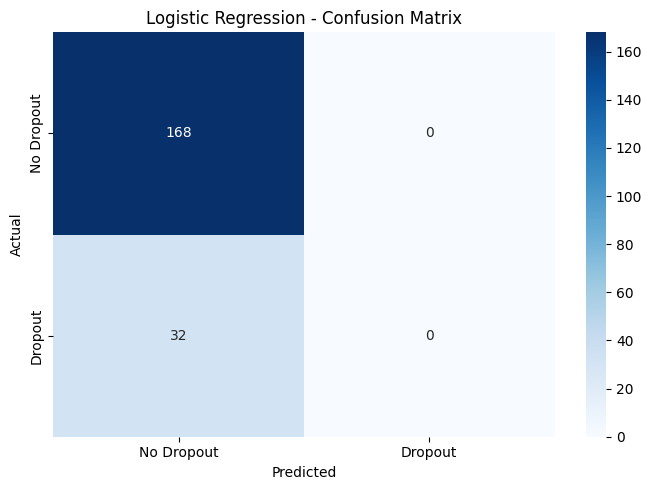

In [ ]:
# ==========================
# Confusion Matrix
# ==========================

import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_logistic)

FIGSIZE = (7, 5)

plt.figure(figsize=FIGSIZE)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Dropout", "Dropout"],
    yticklabels=["No Dropout", "Dropout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.tight_layout()
plt.show()

### Interpretation

The **Logistic Regression model** classified all 200 participants in the test set as non-dropouts. As a result, it correctly identified all 168 participants who remained in the trial, but failed to identify any of the 32 participants who dropped out.

Although the model achieved an accuracy of 84.0%, this result is misleading because the target variable is imbalanced, with only 16.1% of participants belonging to the dropout class. A naive model predicting the majority class for every participant would achieve approximately the same accuracy.

The model obtained a recall, precision, and F1-score of 0 for the dropout class, indicating that it failed to identify any actual dropout cases.

The ROC-AUC of 0.526 indicates very limited discriminative ability, only slightly above random classification. The PR-AUC of 0.219 is somewhat higher than the dropout prevalence (16.1%), suggesting a weak predictive signal, but not enough to provide reliable discrimination.

Overall, the baseline Logistic Regression model **does not provide useful dropout detection** in its current configuration. This result highlights both the strong class imbalance and the limited predictive signal available in the selected features.

##5. Balanced Logistic Regression
`class_weight="balanced"`
###Question: **Does accounting for class imbalance improve the model's ability to identify dropout cases?**

In [ ]:
# ==========================
# Balanced Logistic Regression
# ==========================

logistic_balanced_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            random_state=42
        ))
    ]
)

###5.1 Training

In [ ]:
logistic_balanced_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Adverse_Events',
                                                   'Systolic_BP',
                                                   'Diastolic_BP',
                                                   'Cholesterol_Level',
                                                   'Time_Since_Start']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',
                                                   'Treatment_Group'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', random_state=42))])

###5.2 Prediction

In [ ]:
y_pred_logistic_balanced = logistic_balanced_pipeline.predict(X_test)

y_prob_logistic_balanced = (
    logistic_balanced_pipeline.predict_proba(X_test)[:, 1]
)

###5.3 Evaluation

In [ ]:
# ==========================
# Balanced Logistic Regression Evaluation
# ==========================

accuracy_balanced = accuracy_score(
    y_test,
    y_pred_logistic_balanced
)

precision_balanced = precision_score(
    y_test,
    y_pred_logistic_balanced,
    zero_division=0
)

recall_balanced = recall_score(
    y_test,
    y_pred_logistic_balanced,
    zero_division=0
)

f1_balanced = f1_score(
    y_test,
    y_pred_logistic_balanced,
    zero_division=0
)

roc_auc_balanced = roc_auc_score(
    y_test,
    y_prob_logistic_balanced
)

pr_auc_balanced = average_precision_score(
    y_test,
    y_prob_logistic_balanced
)

print(f"Accuracy:  {accuracy_balanced:.3f}")
print(f"Precision: {precision_balanced:.3f}")
print(f"Recall:    {recall_balanced:.3f}")
print(f"F1-score:  {f1_balanced:.3f}")
print(f"ROC-AUC:   {roc_auc_balanced:.3f}")
print(f"PR-AUC:    {pr_auc_balanced:.3f}")

Accuracy:  0.565
Precision: 0.176
Recall:    0.469
F1-score:  0.256
ROC-AUC:   0.511
PR-AUC:    0.210


In [ ]:
print(classification_report(
    y_test,
    y_pred_logistic_balanced,
    zero_division=0
))

              precision    recall  f1-score   support

           0       0.85      0.58      0.69       168
           1       0.18      0.47      0.26        32

    accuracy                           0.56       200
   macro avg       0.51      0.53      0.47       200
weighted avg       0.74      0.56      0.62       200



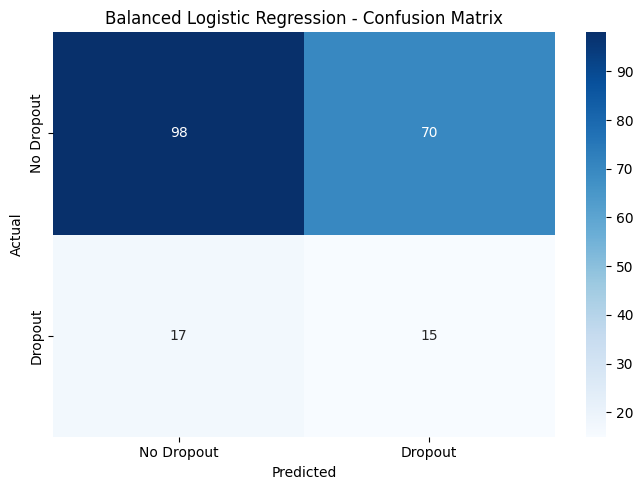

In [ ]:
#Confusion Matrix
cm_balanced = confusion_matrix(
    y_test,
    y_pred_logistic_balanced
)

plt.figure(figsize=FIGSIZE)

sns.heatmap(
    cm_balanced,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Dropout", "Dropout"],
    yticklabels=["No Dropout", "Dropout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Balanced Logistic Regression - Confusion Matrix")

plt.tight_layout()
plt.show()

### Interpretation

Introducing **class weighting** substantially changed the classification behavior of the Logistic Regression model. Unlike the baseline model, which classified all participants as non-dropouts, the balanced model identified 15 of the 32 actual dropout cases, achieving a recall of 46.9%.

However, this improvement came at the cost of a large number of false positives. The model classified 85 participants as potential dropouts, but only 15 of them actually dropped out, resulting in a precision of 17.6% and an overall accuracy of 56.5%.

More importantly, the ROC-AUC decreased from 0.526 to 0.511, while PR-AUC decreased from 0.219 to 0.210. These values remain close to the level expected from a model with limited discriminative ability.

Therefore, class weighting improved the model's ability to identify the minority class, but did not improve its underlying predictive discrimination. This suggests that the poor baseline performance cannot be attributed solely to class imbalance and may also reflect limited predictive signal in the available features.

##6. Random Forest
###Question: **Can a non-linear model identify predictive patterns in the clinical variables that were not captured by Logistic Regression?**

Random Forest was selected as a more flexible model capable of capturing non-linear relationships and interactions between predictors.

Because the target variable is imbalanced, with only 16.1% of participants experiencing dropout, the model will use `class_weight="balanced"` to give greater importance to the minority class during training.

The Random Forest model will be evaluated using the same metrics as Logistic Regression, allowing a direct comparison between the two approaches.

###6.1 Import Random Forest

In [ ]:
# ==========================
# Random Forest
# ==========================

from sklearn.ensemble import RandomForestClassifier

###6.2 Pipeline

In [ ]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        ))
    ]
)

###6.3 Training

In [ ]:
random_forest_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Adverse_Events',
                                                   'Systolic_BP',
                                                   'Diastolic_BP',
                                                   'Cholesterol_Level',
                                                   'Time_Since_Start']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender',
                                                   'Treatment_Group'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

###6.4 Prediction

In [ ]:
y_pred_rf = random_forest_pipeline.predict(X_test)

In [ ]:
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [ ]:
print("Actual Dropout:")
print(y_test.value_counts())

print("\nPredicted Dropout:")
print(pd.Series(y_pred_rf).value_counts())

Actual Dropout:
Dropout
0    168
1     32
Name: count, dtype: int64

Predicted Dropout:
0    199
1      1
Name: count, dtype: int64


In [ ]:
print("Predicted classes:")
print(y_pred_rf[:20])

print("\nPredicted probabilities:")
print(y_prob_rf[:20])

Predicted classes:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

Predicted probabilities:
[0.17 0.34 0.17 0.24 0.15 0.15 0.1  0.13 0.05 0.09 0.31 0.2  0.2  0.26
 0.14 0.18 0.15 0.36 0.17 0.21]


###6.6 Evaluation

In [ ]:
# ==========================
# Random Forest Evaluation
# ==========================

accuracy_rf = accuracy_score(
    y_test,
    y_pred_rf
)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    zero_division=0
)

roc_auc_rf = roc_auc_score(
    y_test,
    y_prob_rf
)

pr_auc_rf = average_precision_score(
    y_test,
    y_prob_rf
)

print(f"Accuracy:  {accuracy_rf:.3f}")
print(f"Precision: {precision_rf:.3f}")
print(f"Recall:    {recall_rf:.3f}")
print(f"F1-score:  {f1_rf:.3f}")
print(f"ROC-AUC:   {roc_auc_rf:.3f}")
print(f"PR-AUC:    {pr_auc_rf:.3f}")

Accuracy:  0.835
Precision: 0.000
Recall:    0.000
F1-score:  0.000
ROC-AUC:   0.626
PR-AUC:    0.201


###6.7 Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.84      0.99      0.91       168
           1       0.00      0.00      0.00        32

    accuracy                           0.83       200
   macro avg       0.42      0.50      0.46       200
weighted avg       0.70      0.83      0.76       200



###6.8 Confusion Matrix

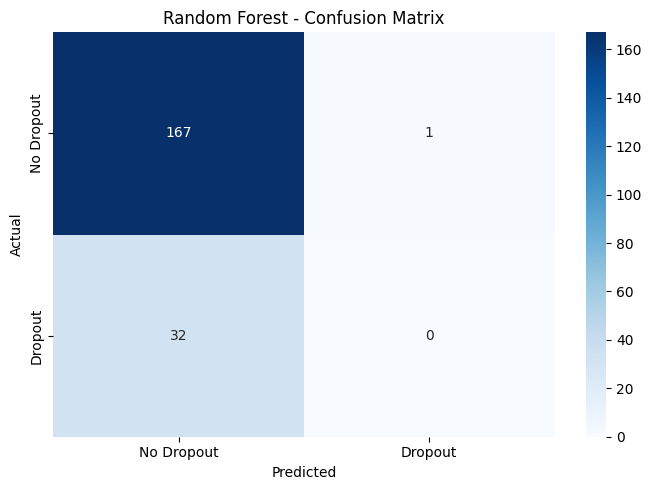

In [ ]:
# ==========================
# Random Forest - Confusion Matrix
# ==========================

cm_rf = confusion_matrix(
    y_test,
    y_pred_rf
)

plt.figure(figsize=FIGSIZE)

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Dropout", "Dropout"],
    yticklabels=["No Dropout", "Dropout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest - Confusion Matrix")

plt.tight_layout()
plt.show()

### Interpretation

The **Random Forest model** achieved an accuracy of 83.5%, but this metric is strongly influenced by the class imbalance in the target variable. Using the default classification threshold of 0.5, the model classified almost all participants as non-dropouts and failed to identify any of the 32 actual dropout cases.

However, the model showed a higher ROC-AUC (0.626) than both Logistic Regression models (0.526 and 0.511). This suggests that Random Forest is capturing some predictive patterns that were not captured by the linear models.

Despite this improvement, the PR-AUC was only 0.201, compared with a dropout prevalence of approximately 16.1%. Therefore, the predictive signal remains weak.

The predicted probabilities also remained below 0.5, explaining why the model classified almost all participants as non-dropouts using the default decision threshold.

Overall, Random Forest provides evidence of a modest non-linear signal in the available features, but its predictive performance remains limited under the default classification threshold.

## 7. Random Forest Hyperparameter Tuning


### Question: **Can hyperparameter tuning improve the Random Forest's ability to distinguish participants who drop out from those who remain in the clinical trial?**

###**Objective**

The initial Random Forest model showed a higher ROC-AUC than Logistic Regression, suggesting that the non-linear model may be capturing predictive patterns that were not identified by the linear models.

However, its predictive performance remains limited.

The objective of hyperparameter tuning is to determine whether a better model configuration can improve its discriminative performance without introducing unnecessary complexity.

Because the target variable is imbalanced, stratified cross-validation will be used to preserve the proportion of dropout and non-dropout cases in each fold.

### **Hyperparameter Search Strategy**

`GridSearchCV` was selected because the dataset is relatively small and the number of hyperparameters to evaluate is limited.

A compact parameter grid will be used instead of an extensive search. This provides a systematic comparison of a manageable number of model configurations while keeping the tuning process computationally efficient and interpretable.

###7.1 Import

In [ ]:
# ==========================
# Hyperparameter Tuning
# ==========================

from sklearn.model_selection import StratifiedKFold, GridSearchCV

###7.2 Define Strategy

In [ ]:
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

###7.3 Define grid

In [ ]:
param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

###7.4 Create GridSearchCV

In [ ]:
grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

###7.5 Training

In [ ]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 36 candidates, totalling 180 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Age',
                                                                          'Adverse_Events',
                                                                          'Systolic_BP',
                                                                          'Diastolic_BP',
                                                                          'Cholesterol_Level',
                                                                          'Time_Since_Start']),
                                                                        ('cat',
                                                                         Pipe...eps=[('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['Gender',
                                                                          'Treatment_Group'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200, 300]},
             scoring='roc_auc', verbose=1)

###7.6 Best Configuration

In [ ]:
print("Best parameters:")
print(grid_search.best_params_)

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}


In [ ]:
print("\nBest cross-validation ROC-AUC:")
print(f"{grid_search.best_score_:.3f}")


Best cross-validation ROC-AUC:
0.479


In [ ]:
best_rf_pipeline = grid_search.best_estimator_
print(best_rf_pipeline)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Adverse_Events',
                                                   'Systolic_BP',
                                                   'Diastolic_BP',
                                                   'Cholesterol_Level',
                                                   'Time_Since_Start']),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEnco

###7.7 Comparison

In [ ]:
print(
    f"Best CV ROC-AUC: {grid_search.best_score_:.3f}"
)

Best CV ROC-AUC: 0.479


###7.8 Test

In [ ]:
y_pred_rf_tuned = best_rf_pipeline.predict(X_test)

y_prob_rf_tuned = (
    best_rf_pipeline.predict_proba(X_test)[:, 1]
)

In [ ]:
accuracy_rf_tuned = accuracy_score(
    y_test,
    y_pred_rf_tuned
)

precision_rf_tuned = precision_score(
    y_test,
    y_pred_rf_tuned,
    zero_division=0
)

recall_rf_tuned = recall_score(
    y_test,
    y_pred_rf_tuned,
    zero_division=0
)

f1_rf_tuned = f1_score(
    y_test,
    y_pred_rf_tuned,
    zero_division=0
)

roc_auc_rf_tuned = roc_auc_score(
    y_test,
    y_prob_rf_tuned
)

pr_auc_rf_tuned = average_precision_score(
    y_test,
    y_prob_rf_tuned
)

print(f"Accuracy:  {accuracy_rf_tuned:.3f}")
print(f"Precision: {precision_rf_tuned:.3f}")
print(f"Recall:    {recall_rf_tuned:.3f}")
print(f"F1-score:  {f1_rf_tuned:.3f}")
print(f"ROC-AUC:   {roc_auc_rf_tuned:.3f}")
print(f"PR-AUC:    {pr_auc_rf_tuned:.3f}")

Accuracy:  0.835
Precision: 0.000
Recall:    0.000
F1-score:  0.000
ROC-AUC:   0.543
PR-AUC:    0.172


###7.9 Classification Report

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_rf_tuned,
        zero_division=0
    )
)

              precision    recall  f1-score   support

           0       0.84      0.99      0.91       168
           1       0.00      0.00      0.00        32

    accuracy                           0.83       200
   macro avg       0.42      0.50      0.46       200
weighted avg       0.70      0.83      0.76       200



###7.10 Confusion Matrix

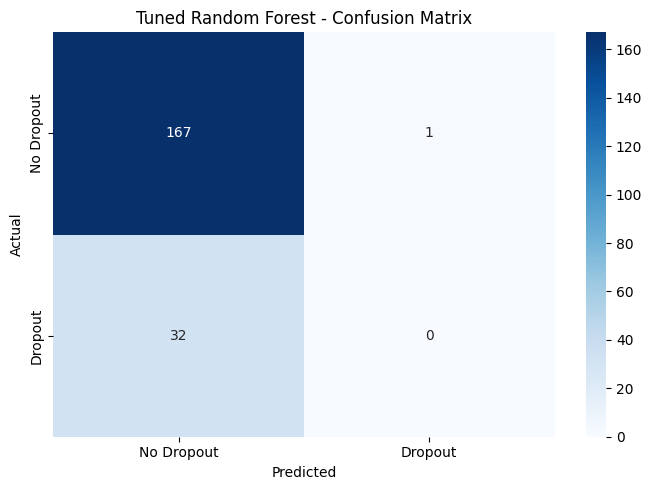

In [ ]:
cm_rf_tuned = confusion_matrix(
    y_test,
    y_pred_rf_tuned
)

plt.figure(figsize=FIGSIZE)

sns.heatmap(
    cm_rf_tuned,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Dropout", "Dropout"],
    yticklabels=["No Dropout", "Dropout"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Tuned Random Forest - Confusion Matrix")

plt.tight_layout()
plt.show()

### Hyperparameter Tuning Interpretation

The hyperparameter tuning process did not improve the Random Forest model's predictive performance.

The best configuration achieved a cross-validation ROC-AUC of 0.479. When evaluated on the previously unseen test set, the tuned model achieved a ROC-AUC of 0.543 and a PR-AUC of 0.172, both lower than those obtained by the initial Random Forest model (ROC-AUC = 0.626; PR-AUC = 0.201).

The tuned model also failed to identify any of the 32 dropout cases using the default classification threshold, resulting in zero recall and zero F1-score for the minority class.

Therefore, further hyperparameter tuning was not considered necessary. The results suggest that model complexity and parameter optimization alone are not sufficient to obtain strong predictive performance from the available features.

###Model Comparison
| Model                        |  Accuracy | Precision | Recall |    F1 |   ROC-AUC |    PR-AUC |
| ---------------------------- | --------: | --------: | -----: | ----: | --------: | --------: |
| Logistic Regression          |     0.840 |     0.000 |  0.000 | 0.000 |     0.526 |     0.219 |
| Balanced Logistic Regression |     0.565 |     0.176 |  0.469 | 0.256 |     0.511 |     0.210 |
| Random Forest                | **0.835** |     0.000 |  0.000 | 0.000 | **0.626** | **0.201** |
| Tuned Random Forest          |     0.835 |     0.000 |  0.000 | 0.000 |     0.543 |     0.172 |


#Executive Summary & Business Recommendations
##Predictive Modeling Outcome

The objective of this project was to evaluate whether the available clinical and demographic information could be used to predict participant dropout in a Phase III clinical trial.

The analysis showed that dropout represents **16.1% of the study population**, resulting in a moderately imbalanced target variable. Exploratory and multivariate analyses revealed limited relationships between the available features and participant dropout.

Two Machine Learning approaches were evaluated: **Logistic Regression** and **Random Forest**. Random Forest achieved the best overall discriminative performance, with a ROC-AUC of 0.626, indicating that the model captures some predictive patterns that were not identified by the linear approach. However, using the standard classification threshold, the model failed to identify actual dropout cases, making it unsuitable for reliable individual-level dropout prediction.

Hyperparameter tuning did not improve the model, with the tuned Random Forest achieving a lower ROC-AUC of 0.543. Therefore, increasing model complexity or adjusting the existing hyperparameters does not appear to be sufficient to obtain a robust predictive solution with the current dataset.

###Key conclusion

**The available features do not provide sufficient predictive signal to develop a robust individual-level dropout prediction model. The main opportunity is therefore not to increase model complexity, but to improve the quality, depth and clinical relevance of the data collected.**

#Key Performance Indicators (KPIs)

Although the current model is not suitable for individual-level prediction, the available data can still support **clinical trial monitoring and retention strategies.**

##The following KPIs are recommended:

###**1.** Overall Dropout Rate

Current observed rate: 16.1%

This should be monitored throughout the study to identify changes in participant retention over time.

###**2.** Dropout Rate by Treatment Group

The observed rates were:

Drug A: 14.47%
Drug B: 18.40%
Placebo: 15.43%

Drug B showed the highest descriptive dropout rate and therefore represents a group that should be monitored closely. However, these differences should not be interpreted as evidence of causality without further statistical and clinical investigation.

###**3.** Dropout Rate by Adverse Event Burden

Monitoring dropout according to the number and severity of adverse events can help identify potential retention risks.

The current analysis does not demonstrate a sufficiently strong relationship to support individual prediction, but adverse-event burden remains a clinically relevant indicator for ongoing monitoring.

###**4.** Dropout Rate Over Trial Time

The engineered variable Time_Since_Start provides a more useful representation of enrollment date than the raw date itself.

Monitoring dropout across different periods of the study could help identify temporal patterns or periods of increased participant attrition.

#Business & Clinical Recommendations
###**1.** Prioritize Data Quality and Data Enrichment

The most important recommendation from this project is to **improve the information available for future predictive modeling.**

Rather than immediately implementing more complex Machine Learning algorithms, the study team should investigate the collection of additional patient-level and operational variables that may better explain participant retention.

Potentially valuable features include:

*   Reason for dropout
*   Severity and type of adverse events
*   Treatment adherence
*   Missed or delayed visits
*   Number of protocol deviations
*   Visit duration and frequency
*   Distance or travel burden to the clinical site
*   Patient-reported experience or satisfaction
*   Concomitant medications
*   Relevant medical history and baseline disease characteristics
*   Previous clinical trial participation
*   Site-level operational indicators

These variables could provide substantially more predictive information than the demographic and basic clinical measurements currently available.


###**2.** Implement Risk-Based Monitoring

Until a sufficiently robust predictive model is developed, the current dataset can still support a **risk-based monitoring strategy**.

The organization could establish thresholds for:

*   Overall dropout rate
*   Dropout rate by treatment group
*   Dropout rate by trial period
*   Adverse-event burden
*   Site-level retention indicators

Participants or groups showing concerning patterns could then **receive additional monitoring or retention interventions.**

###**3.** Investigate the Causes of Dropout

The analysis indicates that predicting who will drop out is difficult with the current variables.

Therefore, an important complementary objective should be understanding why participants drop out.

Collecting structured dropout reasons would allow future analyses to distinguish between:

*   Clinical reasons
*   Treatment-related issues
*   Adverse events
*   Lack of adherence
*   Operational difficulties
*   Patient preferences
*   Logistical or socioeconomic barriers

This would transform dropout analysis from a purely predictive problem into a more **actionable root-cause analysis.**

###**4.** Use the Model as a Benchmark, Not as a Production Tool

The Random Forest model should not **currently be deployed as an automated patient-level dropout prediction system.**

Instead, its ROC-AUC of 0.626 can be considered a baseline benchmark for future modeling efforts.

If richer data become available, future models can be evaluated against this baseline to determine whether the additional information actually improves predictive performance.

#Limitations

Several limitations should be considered when interpreting these results:

*   **Synthetic dataset:** The dataset simulates a Phase III clinical trial and contains artificially embedded anomalies. Therefore, the results cannot be directly generalized to real clinical trials.
*   **Limited sample size:** The dataset contains only 1,000 participants, with 161 dropout cases.
*   **Class imbalance:** Only 16.1% of participants belong to the dropout class, making conventional accuracy an inadequate primary performance metric.
*   **Limited feature availability:** The dataset lacks several behavioral, operational and patient-level factors that may be important determinants of retention.
*   **Data quality issues:** Potentially inconsistent values were identified during EDA, highlighting the importance of data validation in clinical datasets.
*   **Limited predictive performance:** Even the best model did not achieve sufficient performance for reliable individual-level dropout prediction.
*   **No causal inference:** The observed relationships should not be interpreted as evidence that any specific clinical variable causes participant dropout.

#**Next Steps**

The recommended next phase is therefore data enrichment rather than increased model complexity.

A future iteration could follow this strategy:

```
Improve Data Quality
        ↓
Collect Additional Clinical & Operational Features
        ↓
Investigate Root Causes of Dropout
        ↓
Re-run EDA & Feature Engineering
        ↓
Evaluate Predictive Models
        ↓
Validate on External / Real-world Data
        ↓
Consider Deployment for Risk-Based Monitoring
```

